Dataset created and saved as: student_dataset_500.csv

Dataset Preview:
   hours_studied  sleep_hours  attendance  previous_score  final_score
0       2.996321     8.188970   59.256646       66.335725    77.273558
1       7.605714     7.216578   77.095047       63.542731   100.000000
2       5.855952     5.857166   93.647292       31.794945    92.385763
3       4.789268     8.882770   86.611244       53.887348   100.000000
4       1.248149     8.108387   90.328057       56.613693    79.265636

Model Evaluation:
MAE: 4.905729224537455
MSE: 39.90347100611664
R² Score: 0.8102953091309604


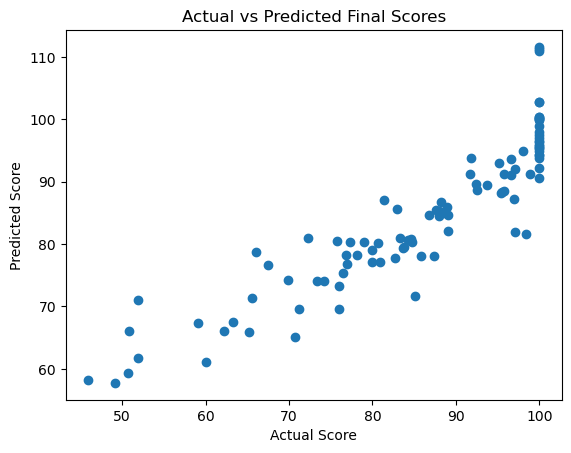

In [2]:
# -----------------------------------------------
# FULL STUDENT SCORE PREDICTION PROJECT
# -----------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------
# 1. Generate 500-row dataset
# ------------------------------
np.random.seed(42)
n = 500

hours = np.random.uniform(0, 8, n)
sleep = np.random.uniform(4, 10, n)
attendance = np.random.uniform(50, 100, n)
previous = np.random.uniform(30, 100, n)

final_score = (
    hours * 7 +
    sleep * 2 +
    attendance * 0.3 +
    previous * 0.4 +
    np.random.normal(0, 5, n)
)
final_score = np.clip(final_score, 0, 100)

df = pd.DataFrame({
    "hours_studied": hours,
    "sleep_hours": sleep,
    "attendance": attendance,
    "previous_score": previous,
    "final_score": final_score
})

df.to_csv("student_dataset_500.csv", index=False)
print("Dataset created and saved as: student_dataset_500.csv")

# ------------------------------
# 2. Load Dataset
# ------------------------------
df = pd.read_csv("student_dataset_500.csv")
print("\nDataset Preview:")
print(df.head())

# ------------------------------
# 3. Split Data
# ------------------------------
X = df[['hours_studied', 'sleep_hours', 'attendance', 'previous_score']]
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 4. Train Model
# ------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------
# 5. Evaluate
# ------------------------------
y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# ------------------------------
# 6. Visualization
# ------------------------------
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Final Scores")
plt.show()
